# Net-Hub — 글로벌 OTT 콘텐츠 수급 및 현지화 전략 분석

> **핵심 질문**: 어떤 콘텐츠를 더 확보해야 하는가?

| 데이터 | 역할 | 핵심 컬럼 |
|---|---|---|
| `netflix_titles.csv` (Kaggle) | **공급** — 어떤 콘텐츠가 깔려 있는가 | 제목, 국가, 장르, 유형 |
| `Engagement Report` (Netflix 공식) | **수요** — 뭘 얼마나 봤는가 | 제목, 시청시간 |

## 15분 발표 흐름

| 구간 | 핵심 질문 | 발표 포인트 |
|---|---|---|
| 1 | 왜 이 분석이 필요한가? | 콘텐츠 수급 의사결정은 공급량만으로 판단하기 어렵고, 시청시간과 함께 봐야 함 |
| 2 | 어떤 데이터를 쓰는가? | Kaggle = 2021년까지 카탈로그 / Engagement = 2023년 상반기 글로벌 시청시간 |
| 3 | 어떻게 연결하는가? | title_key 정제 후 조인, TV Show 필터 + 시즌 정규화 |
| 4 | EDA는 무엇을 확인하는가? | 제작국가·장르를 가중치로 분해해 공급 구조 확인 |
| 5 | 핵심 지표는 무엇인가? | Efficiency Index = Watch Share / Supply Share |
| 6 | 민감도는 왜 보는가? | 상위 인기작 1개가 세그먼트 전체를 왜곡하는지 확인 |
| 7 | 모델링은 왜 하는가? | 규칙 기반 EI를 회귀 모델로 보조 검증 |
| 8 | 최종 결과는 무엇인가? | 대륙별 TOP5 + 한계점 |

## 1. 데이터 로드

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

def find_file(filename):
    candidates = [Path(filename), Path('/mnt/data') / filename, Path.cwd() / filename]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(f'파일을 찾을 수 없습니다: {filename}')

kaggle = pd.read_csv(find_file('netflix_titles.csv'))
engage = pd.read_excel(
    find_file('What_We_Watched_A_Netflix_Engagement_Report_2023Jan-Jun.xlsx'),
    header=5
)
engage = engage.dropna(subset=['Title']).copy()
engage = engage.drop(columns=[c for c in engage.columns if str(c).startswith('Unnamed')])

print(f'Kaggle (공급): {kaggle.shape[0]:,}행 x {kaggle.shape[1]}컬럼')
print(f'Engagement (수요): {engage.shape[0]:,}행 x {engage.shape[1]}컬럼')
display(kaggle.head(3))
display(engage.head(3))

Kaggle (공급): 8,807행 x 12컬럼
Engagement (수요): 18,214행 x 4컬럼


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


,Title,Available Globally?,Release Date,Hours Viewed
0,The Night Agent: Season 1,Yes,2023-03-23,812100000
1,Ginny & Georgia: Season 2,Yes,2023-01-05,665100000
2,The Glory: Season 1 // 더 글로리: 시즌 1,Yes,2022-12-30,622800000


In [2]:
# 결측치 점검
# country 결측은 Unknown으로 보존해 표본을 버리지 않는다
missing = kaggle.isna().mean().mul(100).round(1).sort_values(ascending=False).reset_index()
missing.columns = ['column', 'missing_%']
print('[Kaggle 결측치]')
display(missing)
print(f'\nEngagement 총 시청시간: {engage["Hours Viewed"].sum():,.0f}시간')

[Kaggle 결측치]


,column,missing_%
0,director,29.9
1,cast,9.4
2,country,9.4
3,date_added,0.1
4,title,0.0
5,type,0.0
6,show_id,0.0
7,release_year,0.0
8,rating,0.0
9,duration,0.0



Engagement 총 시청시간: 93,455,200,000시간


## 2. title_key 정제 → TV Show 필터 → 시즌 정규화

**두 데이터를 제목으로 연결**하려면 표기 방식을 통일해야 한다.

| 문제 | 예시 |
|---|---|
| 다국어 병기 | `The Glory: Season 1 // 더 글로리: 시즌 1` |
| 시즌 표기 | `Wednesday: Season 1` vs `Wednesday` |
| 숫자 꼬리 | `Stranger Things 4` vs `Stranger Things` |

두 기준을 비교해 커버리지를 확인한다.

| 기준 | 설명 | 장점 | 한계 |
|---|---|---|---|
| Conservative | 특수문자·병기만 정리 | 과매칭 위험 낮음 | 시즌 표기 차이로 누락 가능 |
| Relaxed | Season/Part/숫자 꼬리도 제거 | 시리즈 단위 매칭 유리 | 시즌 합산 가능 |

**이후 분석은 Relaxed key** — 커버리지 우선, 시즌 합산 편향은 시즌 정규화로 보완.

**시즌 정규화**: Kaggle은 시리즈 전체 1행(`duration="3 Seasons"`), Engagement는 시즌별 별도 행. 시청시간을 시즌 수로 나눠 1시즌당 평균으로 비교.

> 예: Stranger Things 총 3.5억 시간 ÷ 4시즌 = 시즌당 8,700만

In [3]:
def conservative_title_key(x):
    if pd.isna(x): return ''
    x = str(x).lower()
    x = re.sub(r'//.*$', ' ', x)
    x = re.sub(r'[^a-z0-9\s]', ' ', x)
    return re.sub(r'\s+', ' ', x).strip()

SEASON_PAT = re.compile(
    r':\s*(season|limited series|volume|vol\.?|part|chapter|book|collection)\b.*$',
    flags=re.IGNORECASE,
)
NUM_TAIL   = re.compile(r'\s+\d+\s*$')
NON_ALNUM  = re.compile(r'[^a-z0-9\s]')
MULTISPACE = re.compile(r'\s+')

def relaxed_title_key(x):
    if pd.isna(x): return ''
    x = str(x).split('//')[0]
    x = SEASON_PAT.sub('', x)
    x = x.lower()
    x = NON_ALNUM.sub(' ', x)
    x = MULTISPACE.sub(' ', x).strip()
    x = NUM_TAIL.sub('', x).strip()
    return x

kaggle['conservative_key'] = kaggle['title'].map(conservative_title_key)
kaggle['title_key']        = kaggle['title'].map(relaxed_title_key)
engage['conservative_key'] = engage['Title'].map(conservative_title_key)
engage['title_key']        = engage['Title'].map(relaxed_title_key)

print('정규화 예시 (Stranger Things):')
sample = engage[engage['Title'].str.contains('Stranger Things', na=False)]
display(sample[['Title', 'conservative_key', 'title_key']])

정규화 예시 (Stranger Things):


,Title,conservative_key,title_key
60,Stranger Things 4,stranger things 4,stranger things
149,Stranger Things,stranger things,stranger things
176,Stranger Things 2,stranger things 2,stranger things
190,Stranger Things 3,stranger things 3,stranger things
10616,Beyond Stranger Things: Beyond 2,beyond stranger things beyond 2,beyond stranger things beyond


In [4]:
# TV Show만 필터링
kaggle_tv = kaggle[kaggle['type'] == 'TV Show'].copy()
print(f'Kaggle TV Show: {len(kaggle_tv):,}개 / 전체 {len(kaggle):,}개')

# 시즌 수 추출
def extract_seasons(dur):
    if not isinstance(dur, str): return 1
    m = re.search(r'(\d+)\s*[Ss]eason', dur)
    return int(m.group(1)) if m else 1

kaggle_tv['n_seasons_kaggle'] = kaggle_tv['duration'].map(extract_seasons)

# Engagement 집계 (두 기준 모두)
engage_agg_con = engage.groupby('conservative_key', as_index=False).agg(
    hours_viewed=('Hours Viewed', 'sum'), n_seasons_engage=('Title', 'nunique'))
engage_agg_rel = engage.groupby('title_key', as_index=False).agg(
    hours_viewed=('Hours Viewed', 'sum'), n_seasons_engage=('Title', 'nunique'))

merged_con = kaggle_tv.merge(engage_agg_con, on='conservative_key', how='left')
merged_rel = kaggle_tv.merge(engage_agg_rel, on='title_key', how='left')

total = len(kaggle_tv)
match_summary = pd.DataFrame({
    'matching_rule': ['Conservative key', 'Relaxed key'],
    'matched_titles': [merged_con['hours_viewed'].notna().sum(), merged_rel['hours_viewed'].notna().sum()],
    'match_rate_%': [
        round(merged_con['hours_viewed'].notna().sum() / total * 100, 1),
        round(merged_rel['hours_viewed'].notna().sum() / total * 100, 1)
    ],
    'hours_coverage_%': [
        round(merged_con['hours_viewed'].sum() / engage['Hours Viewed'].sum() * 100, 1),
        round(merged_rel['hours_viewed'].sum() / engage['Hours Viewed'].sum() * 100, 1)
    ],
    'pass_KPI_25pct': [
        merged_con['hours_viewed'].notna().sum() / total >= 0.25,
        merged_rel['hours_viewed'].notna().sum() / total >= 0.25
    ],
})
display(match_summary)

Kaggle TV Show: 2,676개 / 전체 8,807개


,matching_rule,matched_titles,match_rate_%,hours_coverage_%,pass_KPI_25pct
0,Conservative key,106,4.0,0.5,False
1,Relaxed key,1746,65.2,41.0,True


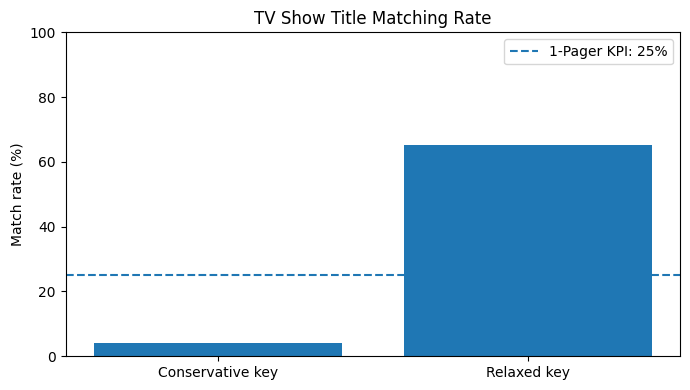

In [5]:
plt.figure(figsize=(7, 4))
plt.bar(match_summary['matching_rule'], match_summary['match_rate_%'])
plt.axhline(25, linestyle='--', label='1-Pager KPI: 25%')
plt.title('TV Show Title Matching Rate')
plt.ylabel('Match rate (%)')
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# Relaxed key + 시즌 정규화로 마스터 테이블 확정
master = merged_rel.copy()
master['n_seasons'] = master[['n_seasons_kaggle', 'n_seasons_engage']].max(axis=1)
master['hours_per_season'] = master['hours_viewed'] / master['n_seasons']
master['matched_flag'] = master['hours_viewed'].notna().astype(int)

print('시즌 정규화 확인 — Stranger Things:')
st = master[master['title'].str.contains('Stranger Things', case=False, na=False)]
display(st[['title', 'n_seasons_kaggle', 'n_seasons_engage', 'n_seasons', 'hours_viewed', 'hours_per_season']])
print(f'\n마스터 테이블: {master.shape[0]:,}행')

시즌 정규화 확인 — Stranger Things:


,title,n_seasons_kaggle,n_seasons_engage,n_seasons,hours_viewed,hours_per_season
1328,Stranger Things,3,4.0,4.0,347600000.0,86900000.0
1860,Beyond Stranger Things,1,NaN,1.0,NaN,NaN



마스터 테이블: 2,676행


## 3. 전처리 — 다중 국가·장르 explode + 가중치 분배

한 콘텐츠에 국가 2개·장르 3개가 있으면 각각 `1/2`, `1/3` 가중치로 분해. 중복 집계 없이 공정하게 나누는 방식.

- `country` 결측 → `Unknown` 보존 (표본 버리지 않음)
- `segment_weight = country_weight x genre_weight`

In [7]:
# 대륙 매핑 (상세)
CONTINENT_MAP = {}
for c in ['Albania','Austria','Belarus','Belgium','Bulgaria','Croatia','Cyprus',
          'Czech Republic','Denmark','East Germany','Finland','France','Germany',
          'Greece','Hungary','Iceland','Ireland','Italy','Latvia','Lithuania',
          'Luxembourg','Netherlands','Norway','Poland','Portugal','Romania',
          'Russia','Serbia','Slovakia','Slovenia','Spain','Sweden','Switzerland',
          'Turkey','Ukraine','United Kingdom','West Germany']:
    CONTINENT_MAP[c] = 'Europe'
for c in ['Afghanistan','Armenia','Azerbaijan','Bangladesh','Cambodia','China',
          'Georgia','Hong Kong','India','Indonesia','Iran','Iraq','Israel',
          'Japan','Jordan','Kazakhstan','Kuwait','Lebanon','Malaysia','Mongolia',
          'Nepal','Pakistan','Philippines','Qatar','Saudi Arabia','Singapore',
          'South Korea','Sri Lanka','Syria','Taiwan','Thailand',
          'United Arab Emirates','Vietnam']:
    CONTINENT_MAP[c] = 'Asia'
for c in ['Algeria','Angola','Egypt','Ethiopia','Ghana','Kenya','Morocco',
          'Nigeria','Senegal','South Africa','Uganda','Zimbabwe']:
    CONTINENT_MAP[c] = 'Africa'
for c in ['Canada','Cuba','Dominican Republic','Guatemala','Jamaica',
          'Mexico','Panama','Puerto Rico','United States']:
    CONTINENT_MAP[c] = 'North America'
for c in ['Argentina','Brazil','Chile','Colombia','Ecuador',
          'Paraguay','Peru','Uruguay','Venezuela']:
    CONTINENT_MAP[c] = 'South America'
for c in ['Australia','New Zealand','Samoa']:
    CONTINENT_MAP[c] = 'Oceania'
CONTINENT_MAP['Unknown'] = 'Unknown'

def split_list(x):
    if pd.isna(x) or str(x).strip() == '':
        return ['Unknown']
    return [item.strip() for item in str(x).split(',') if item.strip()]

def map_rating_group(x):
    if x in ['TV-Y','TV-Y7','TV-G','G']:        return 'Kids'
    elif x in ['PG','PG-13','TV-PG','TV-14']:   return 'Teens'
    elif x in ['R','NC-17','TV-MA']:             return 'Adults'
    elif x in ['NR','UR']:                       return 'Not Rated'
    else:                                        return 'Unknown'

master['date_added']  = pd.to_datetime(master['date_added'], errors='coerce')
master['year_added']  = master['date_added'].dt.year
master['rating_group'] = master['rating'].map(map_rating_group)
master['country_list'] = master['country'].apply(split_list)
master['genre_list']   = master['listed_in'].apply(split_list)
master['country_weight'] = 1 / master['country_list'].apply(len)
master['genre_weight']   = 1 / master['genre_list'].apply(len)

seg = (
    master.explode('country_list').explode('genre_list')
    .rename(columns={'country_list': 'production_country', 'genre_list': 'genre'})
    .copy()
)
seg['continent']       = seg['production_country'].map(CONTINENT_MAP).fillna('Other')
seg['segment_weight']  = seg['country_weight'] * seg['genre_weight']
seg['weighted_supply'] = seg['segment_weight']
seg['weighted_hours']  = seg['hours_per_season'].fillna(0) * seg['segment_weight']

print(f'세그먼트 분석용 행 수: {len(seg):,}')
display(seg[['title','production_country','continent','genre','n_seasons',
             'segment_weight','hours_per_season','weighted_hours']].head(5))

세그먼트 분석용 행 수: 6,879


,title,production_country,continent,genre,n_seasons,segment_weight,hours_per_season,weighted_hours
0,Blood & Water,South Africa,Africa,International TV Shows,3.0,0.333333,9.066667e+06,3.022222e+06
0,Blood & Water,South Africa,Africa,TV Dramas,3.0,0.333333,9.066667e+06,3.022222e+06
0,Blood & Water,South Africa,Africa,TV Mysteries,3.0,0.333333,9.066667e+06,3.022222e+06
1,Ganglands,Unknown,Unknown,Crime TV Shows,2.0,0.333333,4.265000e+07,1.421667e+07
1,Ganglands,Unknown,Unknown,International TV Shows,2.0,0.333333,4.265000e+07,1.421667e+07


## 4. EDA — 제작국가별 공급 구조

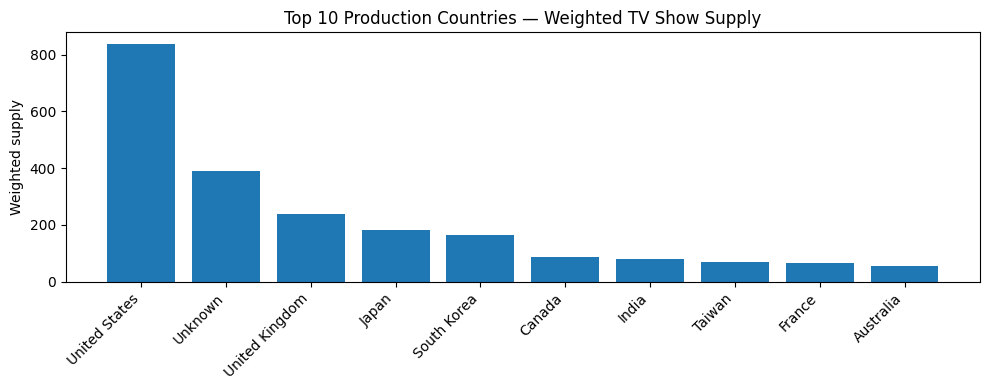

In [8]:
country_supply = (
    seg.drop_duplicates(subset=['show_id', 'production_country'])
    .groupby('production_country', as_index=False)
    .agg(weighted_titles=('country_weight', 'sum'))
    .sort_values('weighted_titles', ascending=False).head(10)
)
plt.figure(figsize=(10, 4))
plt.bar(country_supply['production_country'], country_supply['weighted_titles'])
plt.title('Top 10 Production Countries — Weighted TV Show Supply')
plt.ylabel('Weighted supply')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. EDA — 장르별 공급 구조

,genre,weighted_supply
5,International TV Shows,505.5
6,Kids' TV,326.7
15,TV Dramas,311.2
14,TV Comedies,277.7
4,Docuseries,215.2
3,Crime TV Shows,169.0
8,Reality TV,162.2
9,Romantic TV Shows,128.3
1,British TV Shows,93.0
0,Anime Series,85.3


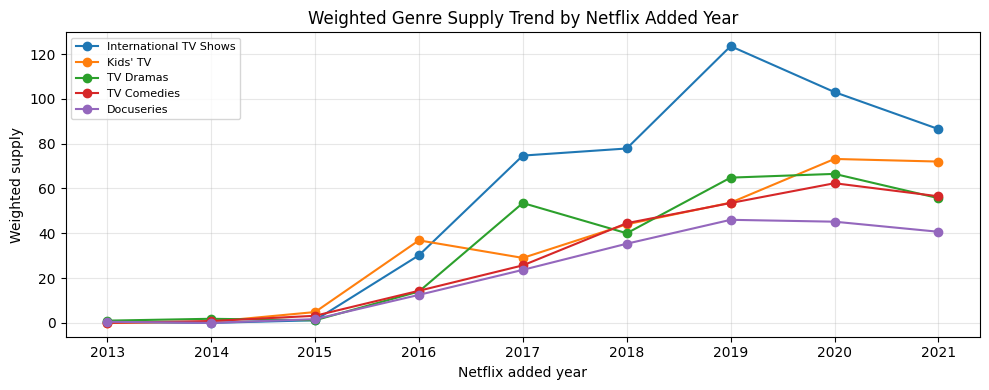

In [9]:
genre_supply = (
    seg.drop_duplicates(subset=['show_id', 'genre'])
    .groupby('genre', as_index=False)
    .agg(weighted_supply=('genre_weight', 'sum'))
    .sort_values('weighted_supply', ascending=False)
)
display(genre_supply.head(10).round(1))

top5_genres = genre_supply.head(5)['genre'].tolist()
genre_year = (
    seg[seg['genre'].isin(top5_genres)].dropna(subset=['year_added'])
    .drop_duplicates(subset=['show_id', 'genre', 'year_added'])
    .groupby(['year_added', 'genre'], as_index=False)
    .agg(weighted_supply=('genre_weight', 'sum'))
)
genre_year_pivot = genre_year.pivot(index='year_added', columns='genre', values='weighted_supply').fillna(0)

plt.figure(figsize=(10, 4))
for genre in top5_genres:
    plt.plot(genre_year_pivot.index, genre_year_pivot[genre], marker='o', label=genre)
plt.title('Weighted Genre Supply Trend by Netflix Added Year')
plt.xlabel('Netflix added year')
plt.ylabel('Weighted supply')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Efficiency Index 계산

**EI = Watch Share / Supply Share**

> 전체 카탈로그에서 이 조합이 차지하는 비율 대비, 실제로 얼마나 많이 시청됐는지의 비율.
> 예: EI = 5 → 카탈로그 비중 1%, 시청 비중 5% → **있는 것보다 5배 더 찾아본다**.

| EI 값 | 의미 |
|---|---|
| EI = 1 | 공급과 수요가 균형 |
| EI > 1 | 수요가 공급보다 큼 → 더 확보해야 함 |
| EI < 1 | 이미 충분히 많음 |

단순 EI만 쓰면 표본이 작거나 히트작 1개에 의존한 세그먼트가 과대평가될 수 있다. **rank_score**로 보완.

$$\text{rank\_score} = EI \times \log(1 + \text{matched\_titles}) \times (1 - \text{top\_title\_dependency})$$

In [10]:
seg_summary = (
    seg.groupby(['continent', 'production_country', 'genre'], as_index=False)
    .agg(
        catalog_titles  = ('show_id',         'nunique'),
        matched_titles  = ('matched_flag',    'sum'),
        supply_weight   = ('weighted_supply', 'sum'),
        watch_hours     = ('weighted_hours',  'sum'),
        max_watch_hours = ('weighted_hours',  'max'),
    )
)
seg_summary['supply_share'] = seg_summary['supply_weight'] / seg_summary['supply_weight'].sum()
seg_summary['watch_share']  = seg_summary['watch_hours']   / seg_summary['watch_hours'].sum()
seg_summary['EI']           = seg_summary['watch_share']   / seg_summary['supply_share']
seg_summary['top_title_dependency'] = (
    seg_summary['max_watch_hours'] / seg_summary['watch_hours'].replace(0, np.nan)
)

# 최소 기준 필터
seg_filtered = seg_summary[
    (seg_summary['matched_titles'] >= 5) &
    (seg_summary['supply_weight']  >= 3) &
    (seg_summary['watch_hours']    >  0)
].copy()

seg_filtered['rank_score'] = (
    seg_filtered['EI']
    * np.log1p(seg_filtered['matched_titles'])
    * (1 - seg_filtered['top_title_dependency'].clip(upper=0.99))
)

print(f'전체 세그먼트: {len(seg_summary):,}  ->  최소 기준 통과: {len(seg_filtered):,}')
top10 = seg_filtered.sort_values('rank_score', ascending=False).head(10)
display(
    top10[['continent','production_country','genre','matched_titles',
           'supply_weight','watch_hours','EI','top_title_dependency','rank_score']]
    .assign(
        supply_weight        = lambda d: d['supply_weight'].round(1),
        watch_hours          = lambda d: d['watch_hours'].round(0).map('{:,.0f}'.format),
        EI                   = lambda d: d['EI'].round(2),
        top_title_dependency = lambda d: (d['top_title_dependency']*100).round(1).astype(str)+'%',
        rank_score           = lambda d: d['rank_score'].round(2)
    )
)

전체 세그먼트: 539  ->  최소 기준 통과: 127


,continent,production_country,genre,matched_titles,supply_weight,watch_hours,EI,top_title_dependency,rank_score
433,North America,United States,Romantic TV Shows,29,16.5,"667,142,713",7.94,24.2%,20.49
439,North America,United States,TV Dramas,167,100.5,"1,607,237,499",3.15,10.0%,14.50
509,South America,Colombia,Spanish-Language TV Shows,25,8.2,"214,497,222",5.15,26.4%,12.35
507,South America,Colombia,International TV Shows,25,8.5,"214,497,222",4.95,26.4%,11.87
437,North America,United States,TV Action & Adventure,79,30.4,"465,496,309",3.02,17.7%,10.88
505,South America,Colombia,Crime TV Shows,14,4.7,"151,118,519",6.34,37.5%,10.72
442,North America,United States,TV Sci-Fi & Fantasy,48,20.2,"295,576,204",2.88,16.5%,9.36
145,Asia,South Korea,International TV Shows,107,51.5,"456,575,458",1.74,8.8%,7.45
441,North America,United States,TV Mysteries,36,15.1,"205,959,577",2.68,23.5%,7.41
427,North America,United States,Crime TV Shows,99,51.7,"469,176,382",1.79,13.6%,7.11


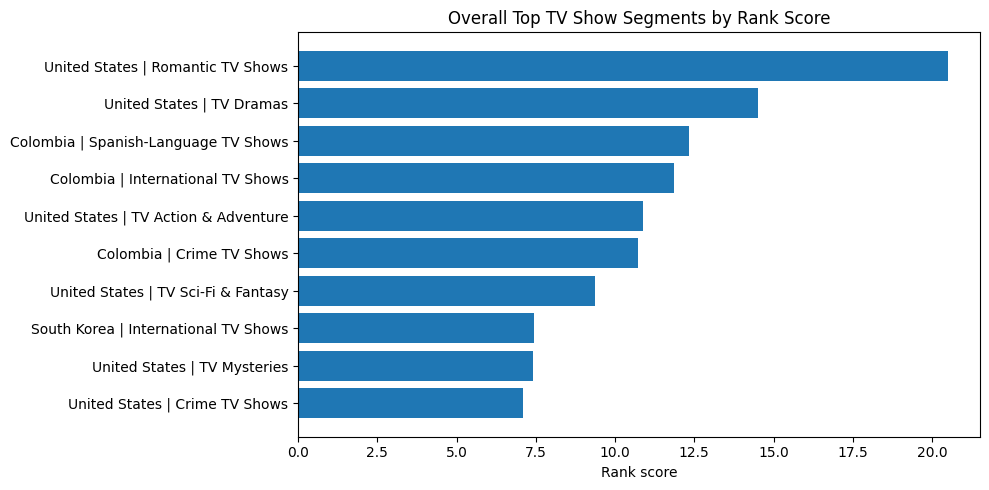

In [11]:
plot_top = top10.copy()
plot_top['segment'] = plot_top['production_country'] + ' | ' + plot_top['genre']
plot_top = plot_top.sort_values('rank_score')

plt.figure(figsize=(10, 5))
plt.barh(plot_top['segment'], plot_top['rank_score'])
plt.title('Overall Top TV Show Segments by Rank Score')
plt.xlabel('Rank score')
plt.tight_layout()
plt.show()

## 7. 민감도 분석 — 히트작 1개가 결과를 왜곡하는가?

EI가 높더라도 타이틀 1개가 전체 시청시간을 대부분 차지한다면 해당 세그먼트는 안정적인 수급 후보로 보기 어렵다.

$$\text{Top Title Dependency} = \frac{\text{세그먼트 내 최대 타이틀 시청시간}}{\text{세그먼트 전체 시청시간}}$$

- 값이 낮을수록 여러 타이틀이 고르게 성과
- 값이 높을수록 단일 작품 의존

/tmp/ipykernel_548/413905918.py:8: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_548/413905918.py:8: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_548/413905918.py:8: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_fig

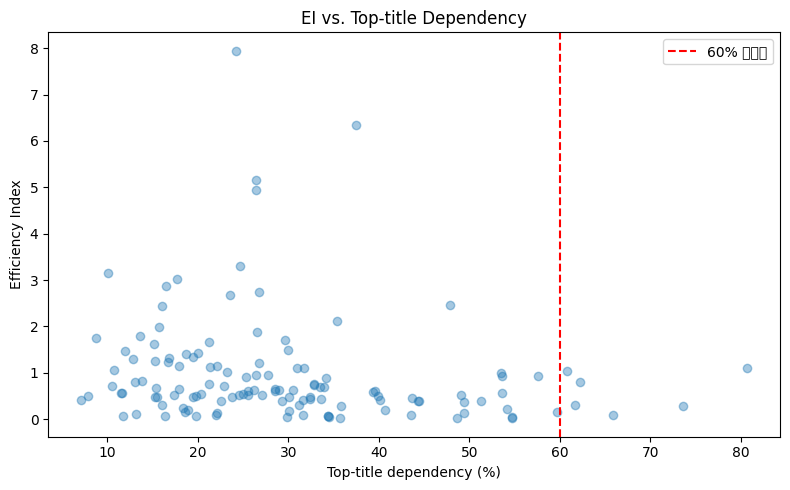

최소 기준 통과: 127  ->  의존도 <=60%: 121


,continent,production_country,genre,matched_titles,EI,top_title_dependency,rank_score
433,North America,United States,Romantic TV Shows,29,7.94,24.2%,20.49
439,North America,United States,TV Dramas,167,3.15,10.0%,14.50
509,South America,Colombia,Spanish-Language TV Shows,25,5.15,26.4%,12.35
507,South America,Colombia,International TV Shows,25,4.95,26.4%,11.87
437,North America,United States,TV Action & Adventure,79,3.02,17.7%,10.88
505,South America,Colombia,Crime TV Shows,14,6.34,37.5%,10.72
442,North America,United States,TV Sci-Fi & Fantasy,48,2.88,16.5%,9.36
145,Asia,South Korea,International TV Shows,107,1.74,8.8%,7.45
441,North America,United States,TV Mysteries,36,2.68,23.5%,7.41
427,North America,United States,Crime TV Shows,99,1.79,13.6%,7.11


In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(seg_filtered['top_title_dependency'] * 100, seg_filtered['EI'], alpha=0.4)
plt.axvline(60, linestyle='--', color='red', label='60% 기준선')
plt.title('EI vs. Top-title Dependency')
plt.xlabel('Top-title dependency (%)')
plt.ylabel('Efficiency Index')
plt.legend()
plt.tight_layout()
plt.show()

stable = seg_filtered[seg_filtered['top_title_dependency'] <= 0.60].copy()
print(f'최소 기준 통과: {len(seg_filtered):,}  ->  의존도 <=60%: {len(stable):,}')

display(
    stable.sort_values('rank_score', ascending=False).head(10)[
        ['continent','production_country','genre','matched_titles','EI','top_title_dependency','rank_score']
    ].assign(
        EI                   = lambda d: d['EI'].round(2),
        top_title_dependency = lambda d: (d['top_title_dependency']*100).round(1).astype(str)+'%',
        rank_score           = lambda d: d['rank_score'].round(2)
    )
)

## 8. 대륙별 Top 5

전체 순위는 북미(미국)에 쏠린다. 글로벌 수급 전략은 지역별 포트폴리오로 봐야 하므로 대륙별로 나눠 확인한다.

각 권역 내에서 표본 크기에 비례한 임계값 자동 적용 (권역 supply 합계의 2% 이상).

In [13]:
def continent_top5(continent_name):
    grp = seg[seg['continent'] == continent_name]
    s = grp.groupby('genre').agg(
        supply         = ('weighted_supply', 'sum'),
        hours          = ('weighted_hours',  'sum'),
        n_titles       = ('show_id',         'nunique'),
        matched_titles = ('matched_flag',    'sum'),
        max_hours      = ('weighted_hours',  'max'),
    )
    threshold = s['supply'].sum() * 0.02
    s = s[(s['supply'] >= threshold) & (s['hours'] > 0)].copy()
    if len(s) == 0:
        print(f'[{continent_name}] 조건을 만족하는 세그먼트 없음')
        return
    s['EI']      = (s['hours']/s['hours'].sum()) / (s['supply']/s['supply'].sum())
    s['top_dep'] = s['max_hours'] / s['hours']
    s['rank_score'] = (
        s['EI'] * np.log1p(s['matched_titles']) * (1 - s['top_dep'].clip(upper=0.99))
    )
    top = s.sort_values('rank_score', ascending=False).head(5)
    print(f'\n{"="*62}')
    print(f'  {continent_name} — TV Show 확보 우선순위 Top 5')
    print(f'{"="*62}')
    for rank, (genre, row) in enumerate(top.iterrows(), 1):
        print(f'  {rank}위  {genre:35s} | EI = {row["EI"]:.1f}  ({int(row["matched_titles"])}개 매칭)')

for cont in ['North America', 'Asia', 'Europe', 'South America', 'Oceania', 'Africa']:
    continent_top5(cont)
print()


  North America — TV Show 확보 우선순위 Top 5
  1위  TV Dramas                           | EI = 2.2  (198개 매칭)
  2위  TV Action & Adventure               | EI = 2.2  (94개 매칭)
  3위  TV Sci-Fi & Fantasy                 | EI = 2.0  (54개 매칭)
  4위  Crime TV Shows                      | EI = 1.3  (131개 매칭)
  5위  Spanish-Language TV Shows           | EI = 1.3  (49개 매칭)

  Asia — TV Show 확보 우선순위 Top 5
  1위  Korean TV Shows                     | EI = 2.1  (88개 매칭)
  2위  International TV Shows              | EI = 1.0  (376개 매칭)
  3위  Romantic TV Shows                   | EI = 1.3  (122개 매칭)
  4위  Crime TV Shows                      | EI = 0.9  (56개 매칭)
  5위  TV Dramas                           | EI = 0.7  (140개 매칭)

  Europe — TV Show 확보 우선순위 Top 5
  1위  Kids' TV                            | EI = 1.5  (96개 매칭)
  2위  Spanish-Language TV Shows           | EI = 2.0  (35개 매칭)
  3위  International TV Shows              | EI = 1.0  (280개 매칭)
  4위  TV Dramas                           | EI = 1.1  (149개 매칭)
  5위

## 9. 모델링 — 규칙 기반 EI를 회귀 모델로 보조 검증

EI는 설명이 쉽고 직관적이지만 단일 비율 지표다. 회귀 모델로 `log1p(watch_hours)`를 예측하고, 고효율 세그먼트의 순위를 어느 정도 재현하는지 확인한다.

| 지표 | 의미 |
|---|---|
| RMSE_log | 로그 시청시간 예측 오차 |
| Spearman | 실제 순위와 예측 순위의 상관 (목적에 가장 중요) |
| Top20%_overlap | 실제·예측 상위 20%의 겹침 |

> 목적은 정확한 예측이 아니라 **우선순위 랭킹 재현 여부** 확인.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import spearmanr

try:
    from lightgbm import LGBMRegressor
    use_lgbm = True
except Exception:
    from sklearn.ensemble import HistGradientBoostingRegressor
    use_lgbm = False

model_df = seg_filtered.copy()
model_df['target'] = np.log1p(model_df['watch_hours'])

cat_cols = ['continent', 'production_country', 'genre']
num_cols = ['supply_weight', 'matched_titles', 'supply_share', 'top_title_dependency']

X = model_df[cat_cols + num_cols]
y = model_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

models = {'Ridge': Ridge(alpha=1.0), 'Lasso': Lasso(alpha=0.001, max_iter=5000)}
if use_lgbm:
    models['LightGBM'] = LGBMRegressor(
        n_estimators=50, learning_rate=0.05, num_leaves=15,
        min_child_samples=5, random_state=42, verbose=-1, n_jobs=1
    )
else:
    models['HistGradientBoosting'] = HistGradientBoostingRegressor(
        max_iter=80, learning_rate=0.05, random_state=42
    )

results = []
for name, model in models.items():
    pipe = Pipeline([('pre', preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rmse  = mean_squared_error(y_test, pred) ** 0.5
    spear = spearmanr(y_test, pred).correlation
    top_n = max(1, int(len(y_test) * 0.2))
    eval_df = pd.DataFrame({'actual': y_test.values, 'pred': pred})
    actual_top = set(eval_df.sort_values('actual', ascending=False).head(top_n).index)
    pred_top   = set(eval_df.sort_values('pred',   ascending=False).head(top_n).index)
    results.append({'model': name, 'RMSE_log': rmse, 'Spearman': spear,
                    'Top20%_overlap': len(actual_top & pred_top) / top_n})

model_results = pd.DataFrame(results).sort_values('Spearman', ascending=False)
display(model_results.round(3))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,RMSE_log,Spearman,Top20%_overlap
0,Ridge,0.853,0.806,0.833
2,LightGBM,0.945,0.798,0.667
1,Lasso,0.883,0.796,0.833


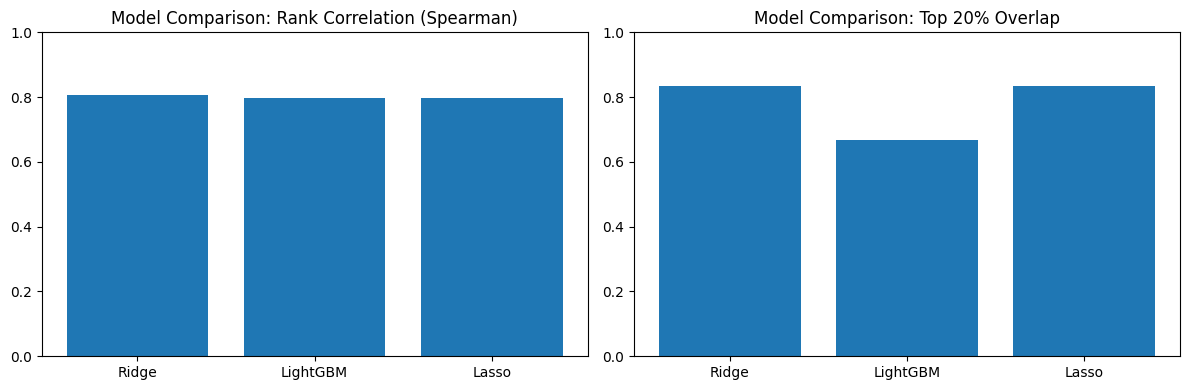

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(model_results['model'], model_results['Spearman'])
axes[0].set_title('Model Comparison: Rank Correlation (Spearman)')
axes[0].set_ylim(0, 1)
axes[1].bar(model_results['model'], model_results['Top20%_overlap'])
axes[1].set_title('Model Comparison: Top 20% Overlap')
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 10. 분석의 한계

**1. 데이터 시점 불일치**
Kaggle은 2021년까지 카탈로그 스냅샷, Engagement는 2023년 상반기. 완전히 같은 시점의 공급·수요가 아님. 매칭 표본은 장기 흥행작으로 자기선택된 집합.

**2. 소비국가 데이터 부재**
`country`는 소비국가가 아니라 제작국가. "한국에서 잘 팔린다"가 아니라 **"한국이 만든 콘텐츠가 글로벌에서 많이 소비됐다"** 는 의미.

**3. title_key 조인 한계**
Relaxed key는 매칭률을 높이지만 일부 과매칭 가능성이 남아 있음. 시즌 정규화로 시즌 합산 편향을 완화했으나 완전히 제거되지는 않음.

**4. 상위 히트작 편향**
시청시간은 소수 인기작에 집중됨. `log1p` 변환, 최소 표본 기준, top_title_dependency로 완화.

**5. EI는 의사결정 보조 지표**
콘텐츠 제작비·라이선스 비용·지역별 구독자 반응은 반영 안 됨. 최종 결론은 **수급 후보군 추천**으로 해석.

---

## 결론

### 핵심 답변: 어떤 콘텐츠를 더 확보해야 하는가?

전체 rank_score 기준으로는 **북미(미국) TV Show** — Romantic, Dramas, Action 장르가 최상위. 글로벌 전략은 대륙별 포트폴리오로 봐야 함.

### 대륙별 비즈니스 시사점

**North America**
로맨틱·드라마·액션 장르가 공급 부족. 미국 제작사 TV Show 라이선스 확보가 가장 즉각적인 ROI 기대 가능 영역.

**Asia**
TV Action & Adventure, Korean TV Shows 상위. 한국 액션·미스터리 시리즈는 북미·아시아를 동시에 커버할 수 있는 전략적 포지션.

**Europe**
TV Action & Adventure, Spanish-Language TV Shows 공급 부족. 스페인어 콘텐츠는 유럽·남미 동시 커버 가능.

**South America**
Crime TV Shows, Spanish-Language 상위. EI가 타 권역 대비 낮아 중장기 현지화 검토 대상.

**Oceania / Africa**
표본이 적어 해석 주의. TV Dramas, Kids' TV 수요 신호 존재.

### 비즈니스 액션

| 우선순위 | 액션 | 근거 |
|---|---|---|
| **1순위** | 미국 로맨틱·드라마 시리즈 라이선스 확보 | 북미 EI 최고 + 표본 안정적 |
| **2순위** | 한국 액션·미스터리 시리즈 확보 | 아시아 EI 상위 + 북미 동시 커버 |
| **3순위** | 유럽 액션 + 스페인어 시리즈 확보 | 유럽 EI 상위 + 남미 동시 커버 |